# 04 - Modelling

Compare four classifiers on the engineered feature matrix, tune the best one, and save it for
the app.

* class imbalance is handled with SMOTE (imbalanced-learn);
* every model is scored with 5-fold stratified cross-validation on accuracy, precision, recall,
  F1 and ROC-AUC;
* the best family is tuned with a random search and scored on the held-out 20%.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import TARGET
from src.metrics import (
    classification_metrics,
    metrics_table,
    plot_confusion,
    plot_feature_importance,
    plot_precision_recall,
    plot_roc_curves,
    plot_threshold_sweep,
)
from src.train import RANDOM_STATE, compare_models, get_models, make_cv, param_grids, tune_model

FIG = PROJECT_ROOT / "reports" / "figures"
MODELS = PROJECT_ROOT / "models"
REPORTS = PROJECT_ROOT / "reports"
sns.set_theme(style="whitegrid")

data = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "telco_features.csv")
X = data.drop(columns=[TARGET])
y = data[TARGET]
print(X.shape, y.mean().round(3))

(7043, 29) 0.265


## Handling the imbalance

SMOTE synthesises new minority-class rows by interpolating between neighbouring churners,
bringing the classes to 50/50 so the models do not just learn to say "stays".

In [2]:
smote = SMOTE(random_state=RANDOM_STATE)
X_res, y_res = smote.fit_resample(X, y)
print("before:", y.value_counts().to_dict())
print("after :", y_res.value_counts().to_dict())

before: {0: 5174, 1: 1869}
after : {0: 5174, 1: 5174}


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=RANDOM_STATE
)
X_train.shape, X_test.shape

((8278, 29), (2070, 29))

## Cross-validated comparison

In [4]:
models = get_models()
cv = make_cv(5)
comparison = compare_models(models, X_train, y_train, cv=cv)
comparison.round(4)

,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,fit_time_s
model,,,,,,,,,,,
Logistic Regression,0.8134,0.0136,0.7965,0.0118,0.8417,0.0169,0.8185,0.0137,0.9027,0.0066,0.1776
Random Forest,0.8246,0.0108,0.8014,0.0122,0.8632,0.0110,0.8311,0.0101,0.9041,0.0058,0.7272
XGBoost,0.8274,0.0096,0.8057,0.0102,0.8630,0.0143,0.8333,0.0095,0.9101,0.0041,0.9847
LightGBM,0.8369,0.0083,0.8215,0.0090,0.8611,0.0134,0.8407,0.0085,0.9151,0.0057,0.7550


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.8134,0.7965,0.8417,0.8185,0.9027
Random Forest,0.8246,0.8014,0.8632,0.8311,0.9041
XGBoost,0.8274,0.8057,0.8630,0.8333,0.9101
LightGBM,0.8369,0.8215,0.8611,0.8407,0.9151


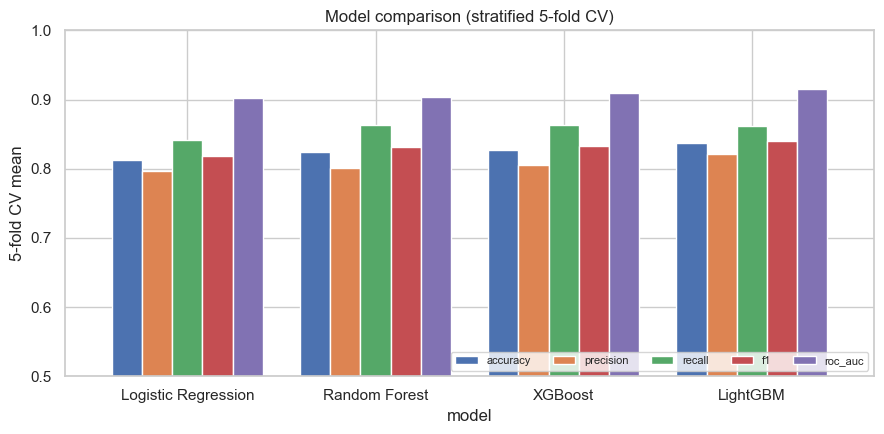

In [5]:
means = comparison[[f"{m}_mean" for m in ["accuracy", "precision", "recall", "f1", "roc_auc"]]]
means.columns = ["accuracy", "precision", "recall", "f1", "roc_auc"]
means.round(4).to_csv(REPORTS / "model_comparison.csv")

fig, ax = plt.subplots(figsize=(9, 4.5))
means.plot.bar(ax=ax, width=0.8)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("5-fold CV mean")
ax.set_title("Model comparison (stratified 5-fold CV)")
ax.legend(loc="lower right", ncol=5, fontsize=8)
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIG / "12_model_comparison.png")
means.round(4)

In [6]:
best_name = comparison["roc_auc_mean"].idxmax()
print("best by CV ROC-AUC:", best_name)

best by CV ROC-AUC: LightGBM


## Tuning the best model

Random search over the grid in `src/train.py`. Each candidate is trained on the training split
and scored on the held-out split; the best ROC-AUC wins.

In [7]:
best_model, search_log = tune_model(
    models[best_name], param_grids()[best_name], X_train, y_train, X_test, y_test, n_iter=15
)
search_log.head(10)

,iter,roc_auc,subsample,num_leaves,n_estimators,min_child_samples,learning_rate,colsample_bytree
0,9,0.926557,0.85,31,600,40,0.05,1.0
1,3,0.926028,1.00,31,600,40,0.03,0.8
2,4,0.925711,1.00,15,600,40,0.10,0.8
3,5,0.925155,0.85,15,600,20,0.05,0.8
4,6,0.925090,0.85,31,200,20,0.10,0.6
5,12,0.921902,1.00,31,400,40,0.03,1.0
6,8,0.921823,0.85,15,600,40,0.10,1.0
7,10,0.921083,1.00,15,400,40,0.05,0.8
8,2,0.919866,0.70,7,600,20,0.05,1.0
9,7,0.919796,0.85,7,400,20,0.10,0.6


In [8]:
best_params = best_model.get_params()
{k: best_params[k] for k in param_grids()[best_name]}

{'n_estimators': 600,
 'learning_rate': 0.05,
 'num_leaves': 31,
 'min_child_samples': 40,
 'subsample': 0.85,
 'colsample_bytree': 1.0}

## Results on the held-out split

In [9]:
probas = {}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    probas[name] = proba
    results[name] = classification_metrics(y_test, (proba >= 0.5).astype(int), proba)

tuned_proba = best_model.predict_proba(X_test)[:, 1]
tuned_name = f"{best_name} (tuned)"
probas[tuned_name] = tuned_proba
results[tuned_name] = classification_metrics(y_test, (tuned_proba >= 0.5).astype(int), tuned_proba)

table = metrics_table(results)
table.to_csv(REPORTS / "test_metrics.csv")
table

,accuracy,precision,recall,f1,roc_auc,pr_auc
Logistic Regression,0.8222,0.8040,0.8522,0.8274,0.9050,0.9054
Random Forest,0.8314,0.8046,0.8754,0.8385,0.9107,0.8975
XGBoost,0.8295,0.8067,0.8667,0.8356,0.9111,0.9084
LightGBM,0.8478,0.8232,0.8860,0.8534,0.9199,0.9204
LightGBM (tuned),0.8440,0.8290,0.8667,0.8474,0.9266,0.9289


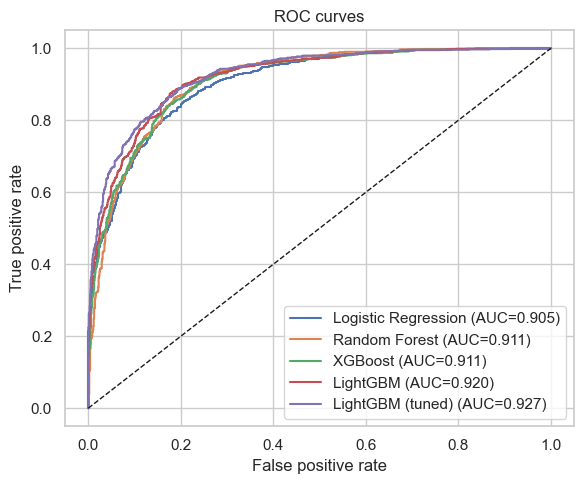

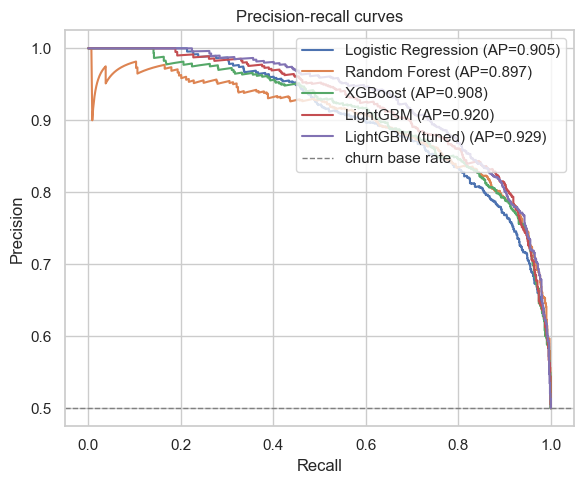

In [10]:
plot_roc_curves(probas, y_test, FIG / "13_roc_curves.png")
plot_precision_recall(probas, y_test, FIG / "14_pr_curves.png");

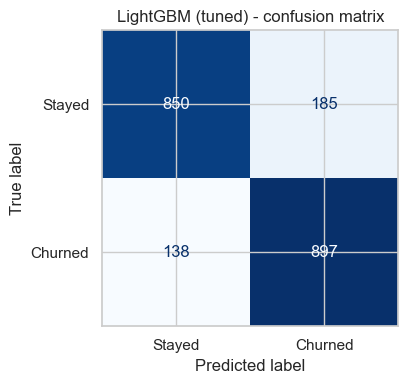

In [11]:
plot_confusion(y_test, (tuned_proba >= 0.5).astype(int), f"{tuned_name} - confusion matrix", FIG / "15_confusion_matrix.png");

## Choosing a decision threshold

The default 0.5 cut-off is not necessarily the right one for a retention campaign. The sweep
below shows the precision/recall trade-off; the app exposes the threshold as a slider so the
business can pick the point that matches their outreach capacity.

,threshold,precision,recall,f1
0,0.10,0.689,0.975,0.807
1,0.15,0.716,0.965,0.822
2,0.20,0.740,0.950,0.832
3,0.25,0.764,0.943,0.844
4,0.30,0.778,0.928,0.846
5,0.35,0.791,0.908,0.846
6,0.40,0.804,0.899,0.849
7,0.45,0.821,0.881,0.850
8,0.50,0.829,0.867,0.847
9,0.55,0.839,0.843,0.841


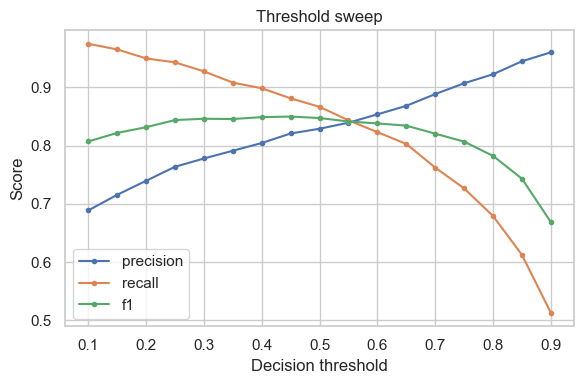

In [12]:
sweep = plot_threshold_sweep(y_test, tuned_proba, FIG / "16_threshold_sweep.png")
sweep.round(3)

## Feature importance

charge_ratio                      3066
tenure                            2565
MonthlyCharges                    2369
TotalCharges                      2365
avg_monthly_charge                2092
num_services                      1038
gender_Male                        508
Partner_Yes                        336
PaymentMethod_Electronic check     332
PaperlessBilling_Yes               297
OnlineBackup_Yes                   282
TechSupport_Yes                    265
dtype: int32

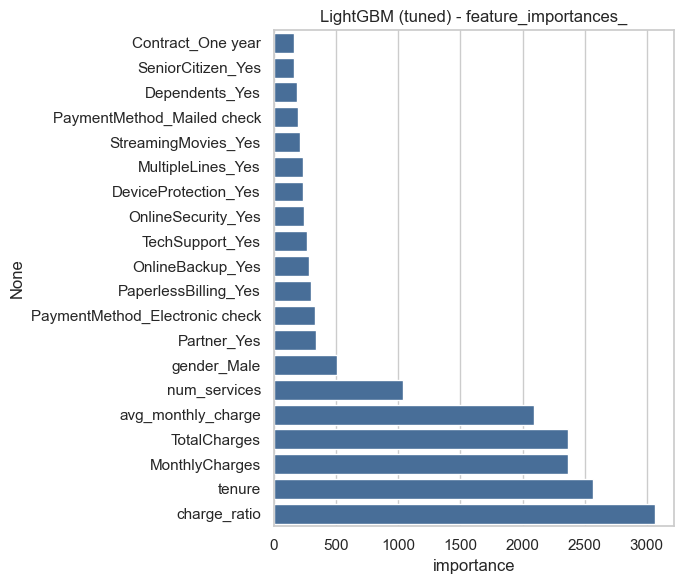

In [13]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    kind = "feature_importances_"
else:
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X.columns)
    kind = "|coef|"
plot_feature_importance(importances, f"{tuned_name} - {kind}", FIG / "17_feature_importance.png")
importances.sort_values(ascending=False).head(12).round(4)

## Save the model

In [14]:
joblib.dump(best_model, MODELS / "churn_model.joblib")

summary = {
    "model": best_name,
    "params": {k: (v.item() if hasattr(v, "item") else v) for k, v in best_params.items() if k in param_grids()[best_name]},
    "threshold": 0.5,
    "cv_comparison": means.round(4).to_dict(orient="index"),
    "test_metrics": table.to_dict(orient="index"),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
}
with open(REPORTS / "metrics.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary["test_metrics"][tuned_name], indent=2))

{
  "accuracy": 0.844,
  "precision": 0.829,
  "recall": 0.8667,
  "f1": 0.8474,
  "roc_auc": 0.9266,
  "pr_auc": 0.9289
}
